In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/sales_data.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,2012-07-31,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,2013-02-05,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,2013-10-17,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,2013-01-28,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,2013-11-05,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [3]:
np.random.seed(42)

df["inventory"] = np.random.randint(10,150,size=len(df))

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,inventory
0,32298,CA-2012-124891,2012-07-31,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical,112
1,26341,IN-2013-77878,2013-02-05,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical,102
2,25330,IN-2013-71249,2013-10-17,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium,24
3,13524,ES-2013-1579342,2013-01-28,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium,116
4,47221,SG-2013-4320,2013-11-05,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical,81


In [4]:
df["price"] = df["Sales"] / df["Quantity"]

In [5]:
df[["Sales","Quantity","price"]].head()

,Sales,Quantity,price
0,2309.650,7,329.950
1,3709.395,9,412.155
2,5175.171,9,575.019
3,2892.510,5,578.502
4,2832.960,8,354.120


In [6]:
df["original_price"] = df["price"]

df["original_revenue"] = df["price"] * df["Quantity"]

original_revenue = df["original_revenue"].sum()

print("Original Revenue:", original_revenue)

Original Revenue: 12642501.909880001


In [7]:
import numpy as np

np.random.seed(42)

df["inventory"] = np.random.randint(10,150,size=len(df))

In [8]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["day_of_week"] = df["Order Date"].dt.dayofweek

In [9]:
df["adjusted_price"] = df["price"]

df.loc[df["Quantity"] >= 5, "adjusted_price"] *= 1.20

In [10]:
df.loc[df["day_of_week"] >= 5, "adjusted_price"] *= 1.15

df.loc[df["inventory"] < 30, "adjusted_price"] *= 1.25

In [11]:
df.loc[df["inventory"] > 120, "adjusted_price"] *= 0.95

df["month"] = df["Order Date"].dt.month

df.loc[df["month"].isin([11,12]), "adjusted_price"] *= 1.20

In [12]:
df["dynamic_revenue"] = df["adjusted_price"] * df["Quantity"]

dynamic_revenue = df["dynamic_revenue"].sum()

In [13]:
revenue_lift = ((dynamic_revenue - original_revenue) / original_revenue) * 100

print("Revenue Lift:", revenue_lift)

Revenue Lift: 20.14104205799076


In [14]:
df[[
    "price",
    "adjusted_price",
    "Quantity",
    "inventory"
]].head(10)

,price,adjusted_price,Quantity,inventory
0,329.950,395.94000,7,112
1,412.155,494.58600,9,102
2,575.019,862.52850,9,24
3,578.502,694.20240,5,116
4,354.120,509.93280,8,81
5,572.535,687.04200,5,30
6,455.520,546.62400,4,112
7,874.140,1145.99754,6,131
8,1016.792,1220.15040,5,84
9,330.588,456.21144,13,97


In [17]:
df["dynamic_revenue"] = df["adjusted_price"] * df["Quantity"]

dynamic_revenue = df["dynamic_revenue"].sum()

print("Original Revenue:", original_revenue)
print("Dynamic Revenue:", dynamic_revenue)
print("Revenue_lift:",revenue_lift)

Original Revenue: 12642501.909880001
Dynamic Revenue: 15188833.536731217
Revenue_lift: 20.14104205799076


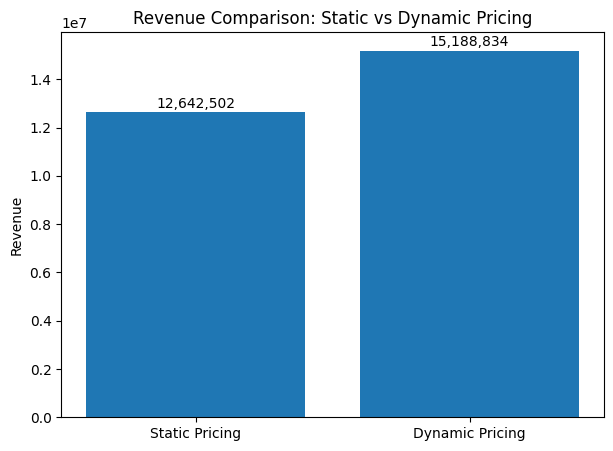

In [19]:
import matplotlib.pyplot as plt

labels = ["Static Pricing", "Dynamic Pricing"]
values = [original_revenue, dynamic_revenue]

plt.figure(figsize=(7,5))
bars = plt.bar(labels, values)

plt.title("Revenue Comparison: Static vs Dynamic Pricing")
plt.ylabel("Revenue")

# add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50000,
             f'{yval:,.0f}', ha='center', va='bottom')

plt.show()

Pricing Engine Results

Original Revenue: 12,642,501
Dynamic Revenue: 15,188,833
Revenue Lift: 20.14%

The rule-based pricing engine increased revenue by approximately 20% compared to static pricing.
This demonstrates that adjusting prices based on demand, time, and inventory conditions can significantly improve business revenue.

This baseline model will serve as a comparison benchmark for the machine learning pricing models in the next milestone.